In [1]:
# Cell 1: imports and project-root setup
import sys
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RAW_METRICS_DIR, TABLES_DIR
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RAW_METRICS_DIR: {RAW_METRICS_DIR}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 2

PROJECT_ROOT: /home/wyuhan/projects/robust-offline-rl-disentanglement
RAW_METRICS_DIR: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics


In [2]:
# Cell 2: parameters
# This notebook compares privileged vs no-privilege pretraining at a fixed hard setting.

TARGET_ENV    = "halfcheetah-medium-v2"
TARGET_TYPE   = "nonlinear"
TARGET_DIMS   = [13, 17]       # noise dims run in the ablation
TARGET_SCALES = [1.5, 2.0]     # noise scales run in the ablation
TARGET_SEEDS  = [1, 2, 3]

# With-privilege methods (existing results)
PRIV_METHODS = [
    "plain",
    "disentangled_barlow",
    "disentangled_hsic",
]

# No-privilege ablation methods (new results)
NO_PRIV_METHODS = [
    "plain_no_priv",
    "disentangled_barlow_no_priv",
    "disentangled_hsic_no_priv",
]

ALL_METHODS = PRIV_METHODS + NO_PRIV_METHODS

method_labels = {
    "plain":                       "Plain (priv)",
    "disentangled_barlow":          "Barlow (priv)",
    "disentangled_hsic":            "HSIC (priv)",
    "plain_no_priv":               "Plain (no-priv)",
    "disentangled_barlow_no_priv": "Barlow (no-priv)",
    "disentangled_hsic_no_priv":   "HSIC (no-priv)",
}

global_order = [
    "Plain (priv)",
    "Plain (no-priv)",
    "Barlow (priv)",
    "Barlow (no-priv)",
    "HSIC (priv)",
    "HSIC (no-priv)",
]

palette = {
    "Plain (priv)":       "#3498db",
    "Plain (no-priv)":    "#aed6f1",
    "Barlow (priv)":      "#f39c12",
    "Barlow (no-priv)":   "#fad7a0",
    "HSIC (priv)":        "#d35400",
    "HSIC (no-priv)":     "#f0b27a",
}

SAVE_FIGURES = True
SAVE_TABLES  = True
SHOW_FIGURES = True

sns.set_theme(style="whitegrid", font_scale=1.1)

In [3]:
# Cell 3: collect results

def infer_method_from_path(path_str, target_methods):
    """Infer method name from directory path. Match longer names first."""
    norm = path_str.replace("\\", "/")
    for method in sorted(target_methods, key=len, reverse=True):
        if f"/{method}/" in norm:
            return method
    return ""

def infer_env_from_path(file_path, target_env):
    """Check if target_env appears as a path component."""
    for part in Path(file_path).parts:
        if part == target_env:
            return part
    return ""

def collect_records(raw_metrics_dir, target_methods, target_env, target_type,
                    target_dims, target_scales, target_seeds):
    records = []
    skipped = {"no_score": 0, "method": 0, "env": 0, "filter": 0}

    for file_path in raw_metrics_dir.rglob("*.json"):
        try:
            with file_path.open("r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception:
            continue

        # Must have a score
        score = data.get("normalized_score")
        if score is None:
            skipped["no_score"] += 1
            continue

        # Method: check JSON fields first, then infer from path
        method = (data.get("method")
                  or data.get("group")
                  or infer_method_from_path(str(file_path), target_methods))
        if not method or method not in target_methods:
            skipped["method"] += 1
            continue

        # Env: JSON may use "env" or "env_name", fall back to path
        env_name = (data.get("env_name")
                    or data.get("env")
                    or infer_env_from_path(file_path, target_env))
        if env_name != target_env:
            skipped["env"] += 1
            continue

        # Noise parameters
        cfg = data.get("data_config", {})
        noise_type  = data.get("noise_type")  or cfg.get("noise_type")
        noise_dim   = data.get("noise_dim")   or cfg.get("noise_dim")
        noise_scale = data.get("noise_scale") or cfg.get("noise_scale")
        seed        = data.get("seed")        or cfg.get("seed")

        if None in (noise_type, noise_dim, noise_scale, seed):
            skipped["filter"] += 1
            continue
        if noise_type != target_type:
            skipped["filter"] += 1
            continue
        if int(noise_dim) not in target_dims:
            skipped["filter"] += 1
            continue
        if float(noise_scale) not in target_scales:
            skipped["filter"] += 1
            continue
        if int(seed) not in target_seeds:
            skipped["filter"] += 1
            continue

        records.append({
            "Method":  method,
            "Dim":     int(noise_dim),
            "Scale":   float(noise_scale),
            "Seed":    int(seed),
            "Score":   float(score),
        })

    return pd.DataFrame(records), skipped


# ---- Run ----
df, skipped = collect_records(
    raw_metrics_dir=RAW_METRICS_DIR,
    target_methods=ALL_METHODS,
    target_env=TARGET_ENV,
    target_type=TARGET_TYPE,
    target_dims=TARGET_DIMS,
    target_scales=TARGET_SCALES,
    target_seeds=TARGET_SEEDS,
)

print(f"Collected {len(df)} records.")
print(f"Skipped breakdown — no_score: {skipped['no_score']}, "
      f"wrong_method: {skipped['method']}, "
      f"wrong_env: {skipped['env']}, "
      f"param_filter: {skipped['filter']}")

if df.empty:
    print("\n[WARN] No records found.")
    print("  → No-priv experiments not yet run? Check: bash scripts/run_all.sh")
    print("  → Priv results available at:")
    for method in PRIV_METHODS:
        method_dir = RAW_METRICS_DIR / method / TARGET_ENV
        if method_dir.exists():
            tags = sorted([d.name for d in method_dir.iterdir() if d.is_dir()])
            matching = [t for t in tags
                        if any(f"ns{str(s).replace('.','p')}" in t for s in TARGET_SCALES)
                        and any(f"nd{d}" in t for d in TARGET_DIMS)]
            print(f"  {method} matching settings: {matching}")
        else:
            print(f"  {method}: not found")
else:
    df["Method Name"] = df["Method"].map(method_labels)
    print("\nData breakdown:")
    print(df.groupby(["Method", "Dim", "Scale"])["Score"].agg(["mean", "count"]).to_string())

Collected 15 records.
Skipped breakdown — no_score: 0, wrong_method: 756, wrong_env: 0, param_filter: 449

Data breakdown:
                                            mean  count
Method                      Dim Scale                  
disentangled_barlow         13  1.5    32.986150      1
                                2.0    25.338131      1
                            17  1.5    31.326772      1
                                2.0    22.396313      1
disentangled_barlow_no_priv 17  2.0    13.707908      1
disentangled_hsic           13  1.5    31.481372      1
                                2.0    26.922867      1
                            17  1.5    34.041843      1
                                2.0    22.043365      1
disentangled_hsic_no_priv   17  2.0    13.406271      1
plain                       13  1.5    32.722581      1
                                2.0    19.693476      1
                            17  1.5    32.017829      1
                                2.0  

In [4]:
# Cell 4: summary table

if df.empty:
    print("[SKIP] No data collected — run experiments first, then re-run this notebook.")
    summary = pd.DataFrame()
else:
    summary = (
        df.groupby(["Method", "Dim", "Scale"], as_index=False)["Score"]
        .agg(mean="mean", std="std", count="count")
    )
    summary["Method Name"] = summary["Method"].map(method_labels)
    summary["Privilege"] = summary["Method"].apply(
        lambda m: "no-priv" if m.endswith("_no_priv") else "priv"
    )

    if SAVE_TABLES:
        out_dir = TABLES_DIR / "ablations" / TARGET_ENV
        out_dir.mkdir(parents=True, exist_ok=True)
        path = out_dir / "no_priv_ablation_summary.csv"
        summary.to_csv(path, index=False)
        print(f"Saved: {path}")

    display(summary)

Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/tables/ablations/halfcheetah-medium-v2/no_priv_ablation_summary.csv


,Method,Dim,Scale,mean,std,count,Method Name,Privilege
0,disentangled_barlow,13,1.5,32.986150,NaN,1,Barlow (priv),priv
1,disentangled_barlow,13,2.0,25.338131,NaN,1,Barlow (priv),priv
2,disentangled_barlow,17,1.5,31.326772,NaN,1,Barlow (priv),priv
3,disentangled_barlow,17,2.0,22.396313,NaN,1,Barlow (priv),priv
4,disentangled_barlow_no_priv,17,2.0,13.707908,NaN,1,Barlow (no-priv),no-priv
5,disentangled_hsic,13,1.5,31.481372,NaN,1,HSIC (priv),priv
6,disentangled_hsic,13,2.0,26.922867,NaN,1,HSIC (priv),priv
7,disentangled_hsic,17,1.5,34.041843,NaN,1,HSIC (priv),priv
8,disentangled_hsic,17,2.0,22.043365,NaN,1,HSIC (priv),priv
9,disentangled_hsic_no_priv,17,2.0,13.406271,NaN,1,HSIC (no-priv),no-priv


Saved figure: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/ablations/halfcheetah-medium-v2/no_priv/scale_sweep_no_priv_dim_13.png


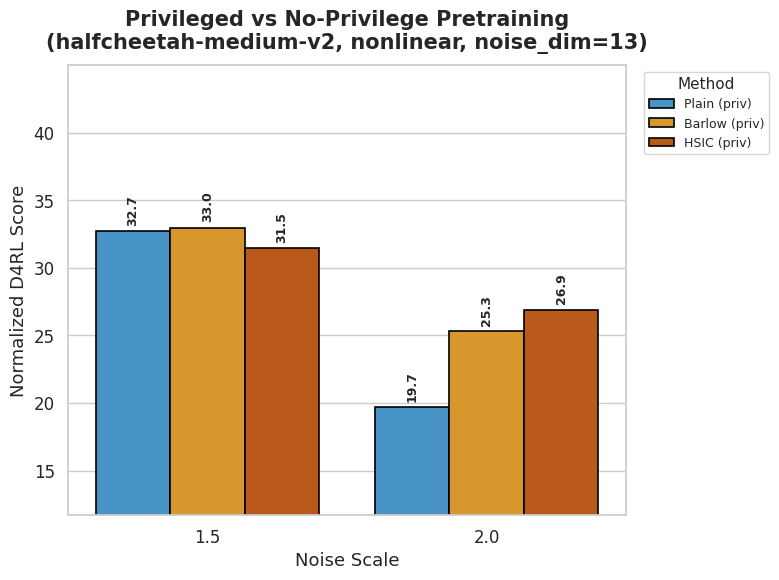

Saved figure: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/ablations/halfcheetah-medium-v2/no_priv/scale_sweep_no_priv_dim_17.png


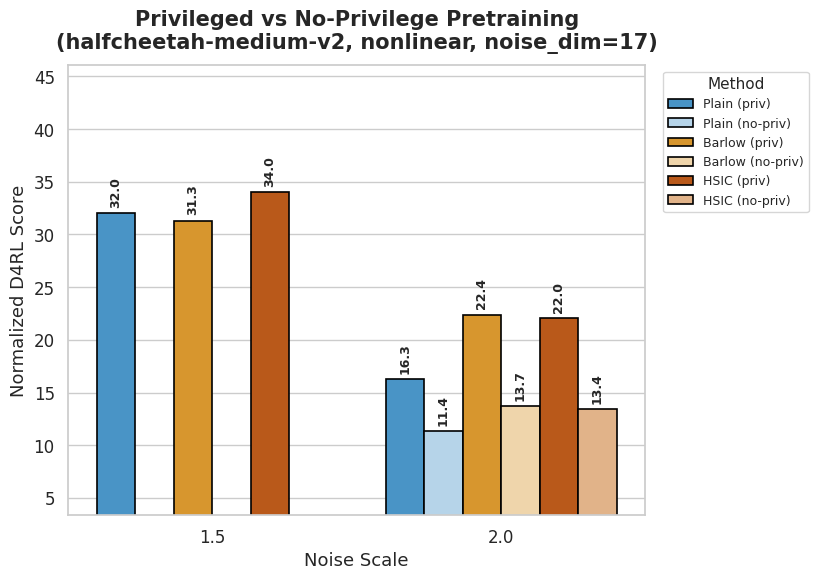

In [5]:
# Cell 5: bar chart — fixed dim, sweep scale

if df.empty:
    print("[SKIP] No data to plot.")
else:
    def plot_comparison(sub_df, x_col, x_label, title, save_path=None):
        if sub_df.empty:
            print(f"No data for: {title}")
            return

        plot_df = sub_df.copy()
        plot_df["Method Name"] = pd.Categorical(
            plot_df["Method Name"],
            categories=[m for m in global_order if m in plot_df["Method Name"].values],
            ordered=True,
        )

        n_x = plot_df[x_col].nunique()
        n_m = plot_df["Method Name"].nunique()
        plt.figure(figsize=(max(8, n_x * n_m * 0.7), 6))

        ax = sns.barplot(
            data=plot_df,
            x=x_col, y="Score",
            hue="Method Name",
            palette=palette,
            edgecolor="black",
            linewidth=1.2,
            capsize=0.05,
        )

        for patch in ax.patches:
            h = patch.get_height()
            if pd.notna(h) and h > 0:
                ax.annotate(
                    f"{h:.1f}",
                    (patch.get_x() + patch.get_width() / 2.0, h),
                    ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points",
                    fontsize=9, fontweight="bold", rotation=90,
                )

        plt.title(title, fontsize=15, fontweight="bold", pad=12)
        plt.xlabel(x_label, fontsize=13)
        plt.ylabel("Normalized D4RL Score", fontsize=13)
        pos_scores = plot_df["Score"][plot_df["Score"] > 0]
        if not pos_scores.empty:
            plt.ylim(max(0, pos_scores.min() - 8), plot_df["Score"].max() + 12)
        plt.legend(
            title="Method", title_fontsize=11, fontsize=9,
            bbox_to_anchor=(1.02, 1), loc="upper left",
        )
        plt.tight_layout()

        if save_path is not None:
            Path(save_path).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved figure: {save_path}")

        if SHOW_FIGURES:
            plt.show()
        else:
            plt.close()

    fig_dir = FIGURES_DIR / "ablations" / TARGET_ENV / "no_priv"

    for dim in TARGET_DIMS:
        sub = df[df["Dim"] == dim]
        save_path = (fig_dir / f"scale_sweep_no_priv_dim_{dim}.png") if SAVE_FIGURES else None
        plot_comparison(
            sub_df=sub, x_col="Scale", x_label="Noise Scale",
            title=f"Privileged vs No-Privilege Pretraining\n"
                  f"({TARGET_ENV}, nonlinear, noise_dim={dim})",
            save_path=save_path,
        )

Saved figure: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/ablations/halfcheetah-medium-v2/no_priv/dim_sweep_no_priv_scale_1p5.png


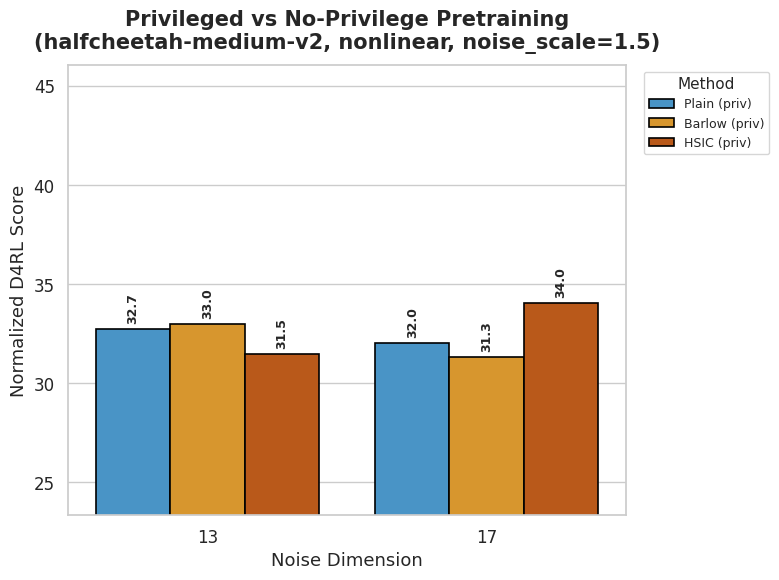

Saved figure: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/ablations/halfcheetah-medium-v2/no_priv/dim_sweep_no_priv_scale_2p0.png


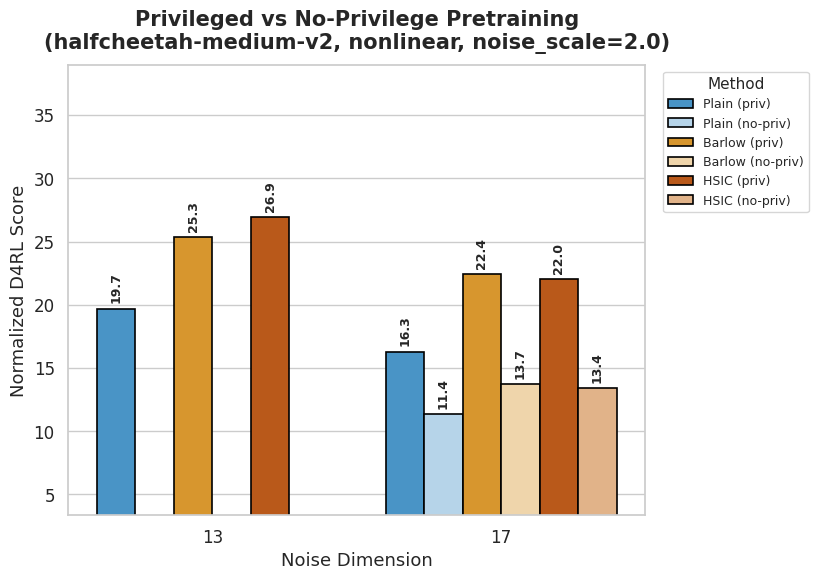

In [6]:
# Cell 6: bar chart — fixed scale, sweep dim

if not df.empty:
    for scale in TARGET_SCALES:
        sub = df[df["Scale"] == scale]
        scale_tag = str(scale).replace(".", "p")
        save_path = (fig_dir / f"dim_sweep_no_priv_scale_{scale_tag}.png") if SAVE_FIGURES else None
        plot_comparison(
            sub_df=sub, x_col="Dim", x_label="Noise Dimension",
            title=f"Privileged vs No-Privilege Pretraining\n"
                  f"({TARGET_ENV}, nonlinear, noise_scale={scale})",
            save_path=save_path,
        )

In [7]:
# Cell 7: gap table — how much does removing privilege cost each method?

if summary.empty:
    print("[SKIP] No summary data available.")
else:
    base_methods = ["plain", "disentangled_barlow", "disentangled_hsic"]
    rows = []
    for m in base_methods:
        priv_scores   = summary.loc[summary["Method"] == m, "mean"]
        nopriv_scores = summary.loc[summary["Method"] == f"{m}_no_priv", "mean"]

        if priv_scores.empty or nopriv_scores.empty:
            print(f"[WARN] Missing data for {m} — skipping gap calculation.")
            continue

        priv_mean   = priv_scores.mean()
        nopriv_mean = nopriv_scores.mean()
        rows.append({
            "Method":               method_labels[m].replace(" (priv)", ""),
            "With Privilege":       round(priv_mean, 2),
            "No Privilege":         round(nopriv_mean, 2),
            "Gap (priv - no_priv)": round(priv_mean - nopriv_mean, 2),
        })

    if rows:
        gap_df = pd.DataFrame(rows)
        print(gap_df.to_string(index=False))

        if SAVE_TABLES:
            out_dir = TABLES_DIR / "ablations" / TARGET_ENV
            out_dir.mkdir(parents=True, exist_ok=True)
            path = out_dir / "no_priv_gap_table.csv"
            gap_df.to_csv(path, index=False)
            print(f"\nSaved: {path}")

Method  With Privilege  No Privilege  Gap (priv - no_priv)
 Plain           25.18         11.36                 13.83
Barlow           28.01         13.71                 14.30
  HSIC           28.62         13.41                 15.22

Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/tables/ablations/halfcheetah-medium-v2/no_priv_gap_table.csv
